In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Libraries loaded.")

Libraries loaded.


In [3]:
plt.rcParams['font.family'] = 'Georgia'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'

BLUE = '#A8BFD0'
SALMON = '#D9B5AE'
PALETTE = [BLUE, SALMON]

print("Style configured.")

Style configured.


In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(f"\nChurn rate: {churn_pct['Yes']:.1f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


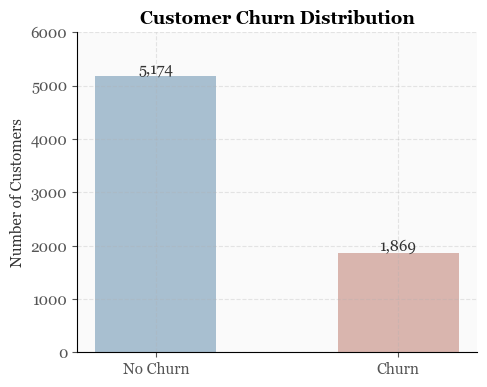

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(['No Churn', 'Churn'],
              [churn_counts['No'], churn_counts['Yes']],
              color=PALETTE, width=0.5, edgecolor='none')

for bar, val in zip(bars, [churn_counts['No'], churn_counts['Yes']]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'{val:,}', ha='center', fontsize=11, color='#333333')

ax.set_title('Customer Churn Distribution')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, 6000)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
cat_cols = df.select_dtypes(include='str').columns.tolist()
print(cat_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [9]:
# Drop customerID (not useful for prediction)
df = df.drop(columns=['customerID'])

# TotalCharges should be numeric — convert and handle errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN appeared after conversion
print("NaN in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# Fill NaN with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert target variable: Yes=1, No=0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("\nChurn value counts after encoding:")
print(df['Churn'].value_counts())

NaN in TotalCharges after conversion: 11

Churn value counts after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
cat_cols = df.select_dtypes(include='str').columns.tolist()
print("Columns to encode:", cat_cols)

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"\nDataset shape after encoding: {df.shape}")
print(df.head())


Dataset shape after encoding: (7043, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                         

In [14]:
# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Features shape: (7043, 30)
Target shape: (7043,)

Training set: 5634 rows
Test set: 1409 rows


In [16]:
# Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=10)
log_reg.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


In [17]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                   random_state=10)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained.")

Random Forest trained.


In [21]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}\n")
    
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

results_log = evaluate_model(y_test, y_pred_log, y_prob_log, "Logistic Regression")
results_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")

--- Logistic Regression ---
Accuracy:  0.7913
Precision: 0.6274
Recall:    0.5267
F1 Score:  0.5727
ROC-AUC:   0.8394

--- Random Forest ---
Accuracy:  0.7906
Precision: 0.6386
Recall:    0.4866
F1 Score:  0.5524
ROC-AUC:   0.8357



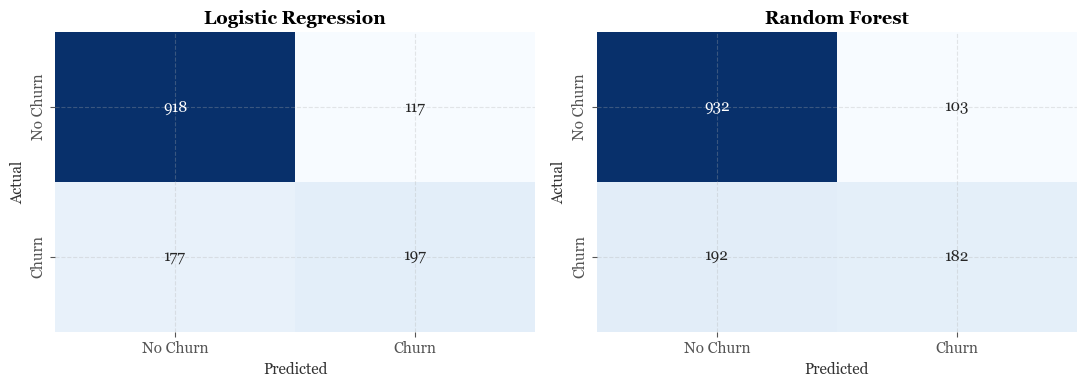

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'], cbar=False)
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'], cbar=False)
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

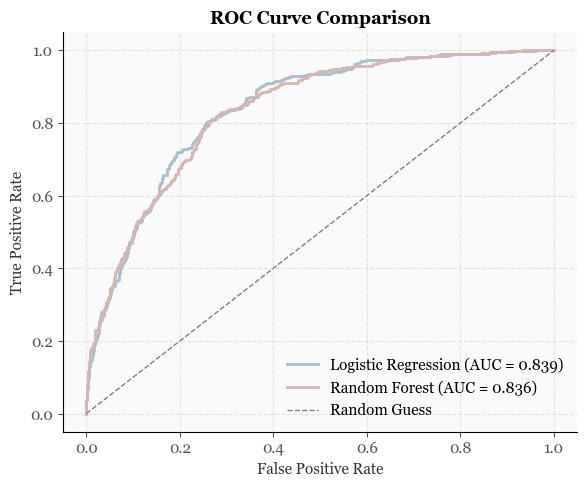

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

ax.plot(fpr_log, tpr_log, color=BLUE, linewidth=2, 
        label=f'Logistic Regression (AUC = {results_log["ROC-AUC"]:.3f})')
ax.plot(fpr_rf, tpr_rf, color=SALMON, linewidth=2, 
        label=f'Random Forest (AUC = {results_rf["ROC-AUC"]:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Guess')

ax.set_title('ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

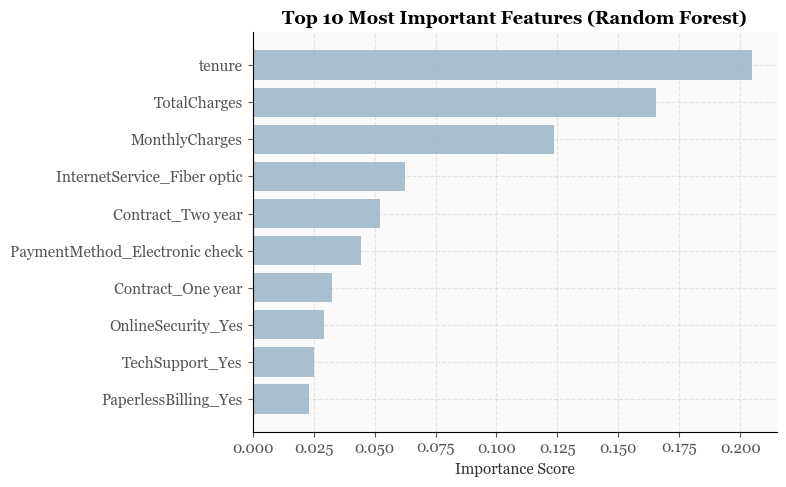

tenure                            0.204787
TotalCharges                      0.165268
MonthlyCharges                    0.123704
InternetService_Fiber optic       0.062428
Contract_Two year                 0.052369
PaymentMethod_Electronic check    0.044389
Contract_One year                 0.032710
OnlineSecurity_Yes                0.029323
TechSupport_Yes                   0.025242
PaperlessBilling_Yes              0.023231
dtype: float64


In [24]:
# Get feature importances from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(top_features.index[::-1], top_features.values[::-1], 
        color=BLUE, edgecolor='none')

ax.set_title('Top 10 Most Important Features (Random Forest)')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_features)

In [25]:
summary = """
## Key Findings

### 1. Model Comparison
Logistic Regression and Random Forest achieved similar overall accuracy
(~79%), but Logistic Regression showed higher Recall (52.7% vs 48.7%) and
ROC-AUC (0.839 vs 0.836). For churn prediction, Recall matters more than
Accuracy: failing to identify a customer who will churn is more costly
than a false alarm. Logistic Regression is the stronger model for this
business objective despite being the simpler algorithm.

### 2. Class Imbalance
Only 26.5% of customers churned. Accuracy alone is a misleading metric
here — a model predicting "no churn" for everyone would still achieve
73.5% accuracy while being completely useless. Recall and ROC-AUC were
prioritized for this reason.

### 3. Key Churn Drivers
Tenure, TotalCharges, and MonthlyCharges are the three strongest predictors
of churn, ahead of any individual service feature. Fiber optic internet
service and two-year contracts also rank highly, suggesting both pricing
structure and contract commitment play major roles in retention.

### Recommendation
Prioritize retention efforts on customers with short tenure, high monthly
charges, and fiber optic service — especially those without long-term
contracts. These customers represent the highest-risk segment based on
feature importance analysis.
"""

from IPython.display import Markdown
display(Markdown(summary))


## Key Findings

### 1. Model Comparison
Logistic Regression and Random Forest achieved similar overall accuracy
(~79%), but Logistic Regression showed higher Recall (52.7% vs 48.7%) and
ROC-AUC (0.839 vs 0.836). For churn prediction, Recall matters more than
Accuracy: failing to identify a customer who will churn is more costly
than a false alarm. Logistic Regression is the stronger model for this
business objective despite being the simpler algorithm.

### 2. Class Imbalance
Only 26.5% of customers churned. Accuracy alone is a misleading metric
here — a model predicting "no churn" for everyone would still achieve
73.5% accuracy while being completely useless. Recall and ROC-AUC were
prioritized for this reason.

### 3. Key Churn Drivers
Tenure, TotalCharges, and MonthlyCharges are the three strongest predictors
of churn, ahead of any individual service feature. Fiber optic internet
service and two-year contracts also rank highly, suggesting both pricing
structure and contract commitment play major roles in retention.

### Recommendation
Prioritize retention efforts on customers with short tenure, high monthly
charges, and fiber optic service — especially those without long-term
contracts. These customers represent the highest-risk segment based on
feature importance analysis.
